# 03 – Convolutional Neural Network (CNN)

Este notebook implementa e avalia modelos CNN para classificação de borboletas (75 classes).

## Experiências realizadas
| Experimento | Arquitectura | Loss | Optimizador |
|-------------|-------------|------|-------------|
| CNN-A_CrossEntropy_RMSprop | Pequena (3 blocos) | CrossEntropy | RMSprop |
| CNN-A_CrossEntropy_Adam    | Pequena (3 blocos) | CrossEntropy | Adam    |
| CNN-A_MultiMargin_RMSprop  | Pequena (3 blocos) | MultiMargin  | RMSprop |
| CNN-A_MultiMargin_Adam     | Pequena (3 blocos) | MultiMargin  | Adam    |
| CNN-B_CrossEntropy_RMSprop | Grande (5 blocos)  | CrossEntropy | RMSprop |
| CNN-B_CrossEntropy_Adam    | Grande (5 blocos)  | CrossEntropy | Adam    |
| CNN-B_MultiMargin_RMSprop  | Grande (5 blocos)  | MultiMargin  | RMSprop |
| CNN-B_MultiMargin_Adam     | Grande (5 blocos)  | MultiMargin  | Adam    |

## 1. Importações e configuração

In [13]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, top_k_accuracy_score
)
import kagglehub

# Reproducibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


## 2. Pipeline de dados

Mantemos o mesmo split 80/20 estratificado e a mesma semente do notebook MLP,
para que a comparação de desempenho seja justa.

### Métricas usadas
- **Accuracy**: métrica primária – dataset ligeiramente desbalanceado (57–105 imgs/classe).
- **Macro F1-Score**: penaliza erros em classes pequenas (complemento à accuracy).
- **Top-5 Accuracy**: útil em 75 classes visualmente semelhantes.
- **Confusion matrix**: inspecção qualitativa de padrões de confusão.

### Data augmentation
As CNNs beneficiam de augmentation mais agressivo do que os MLPs, pois os filtros
são partilhados espacialmente e precisam de aprender invariâncias a rotação/espelho.

In [14]:
# ── Hiperparâmetros globais ─────────────────────────────────────────────────
BATCH_SIZE  = 64
IMAGE_SIZE  = 96        # CNN beneficia de imagens maiores que o MLP (64→96)
NUM_CLASSES = 75
NUM_EPOCHS  = 80
LR          = 1e-3
VAL_SPLIT   = 0.2       # 20 % de validação (igual ao MLP)

# ── Download do dataset ──────────────────────────────────────────────────────
path = kagglehub.competition_download('aca-butterflies')
img_dir   = os.path.join(path, 'train')
train_csv = os.path.join(path, 'train.csv')
print(f'Dataset em: {path}')

df = pd.read_csv(train_csv)
print(f'Total de amostras: {len(df)}  |  Classes: {df["label"].nunique()}')

Dataset em: /Users/matildecarvalho/.cache/kagglehub/competitions/aca-butterflies
Total de amostras: 5199  |  Classes: 75


In [15]:
# ── Mapeamento classe → índice ───────────────────────────────────────────────
classes = sorted(df['label'].unique())
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
print(f'Número de classes: {len(classes)}')

Número de classes: 75


In [16]:
class ButterflyDataset(data.Dataset):
    """Dataset de borboletas para o projeto ACA."""

    def __init__(self, df, img_dir, class_to_idx, transform=None):
        self.img_labels   = df.reset_index(drop=True)
        self.img_dir      = img_dir
        self.class_to_idx = class_to_idx
        self.transform    = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        row      = self.img_labels.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')
        label    = torch.tensor(self.class_to_idx[row['label']], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        return image, label

In [17]:
# ── Transforms ──────────────────────────────────────────────────────────────
# Augmentation mais rico para CNN: espelho, recorte aleatório, colorjitter
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 16, IMAGE_SIZE + 16)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# ── Train / Validation split ─────────────────────────────────────────────────
df_train, df_val = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED,
    stratify=df['label']   # mantém proporção de classes
)
print(f'Treino: {len(df_train)}  | Validação: {len(df_val)}')

train_ds = ButterflyDataset(df_train, img_dir, class_to_idx, train_transform)
val_ds   = ButterflyDataset(df_val,   img_dir, class_to_idx, val_transform)

train_loader = data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = data.DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Batches treino: {len(train_loader)}  |  Batches val: {len(val_loader)}')

Treino: 4159  | Validação: 1040
Batches treino: 65  |  Batches val: 17


## 3. Arquiteturas CNN

### Bloco convolucional
Cada bloco segue o padrão:  
`Conv2d → BatchNorm2d → ReLU → MaxPool2d`

### CNN-A – Pequena (3 blocos)
```
Conv(3→32)  BN ReLU MaxPool(2)   → 32 × 48 × 48
Conv(32→64) BN ReLU MaxPool(2)   → 64 × 24 × 24
Conv(64→128) BN ReLU MaxPool(2)  → 128 × 12 × 12 (com IMAGE_SIZE=96)
Flatten → FC(128·12·12 → 512) BN ReLU Dropout(0.5) → FC(512 → 75)
```
~8.5 M parâmetros.

### CNN-B – Grande (6 blocos + AdaptiveAvgPool)
```
Conv(3→32)   BN ReLU
Conv(32→32)  BN ReLU MaxPool(2)   → 32 × 48 × 48
Conv(32→64)  BN ReLU
Conv(64→64)  BN ReLU MaxPool(2)   → 64 × 24 × 24
Conv(64→128) BN ReLU
Conv(128→128) BN ReLU MaxPool(2)  → 128 × 12 × 12
AdaptiveAvgPool(4×4)              → 128 × 4 × 4
Flatten → FC(128·4·4 → 256) Dropout(0.5) → FC(256 → 75)
```
~2.7 M parâmetros (menos que o MLP!), mais profundo e com melhor regularização.

In [25]:
def conv_block(in_ch, out_ch, pool=True):
    """Bloco Conv → BN → ReLU → (MaxPool)."""
    layers = [
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    ]
    if pool:
        layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)


class CNN_A(nn.Module):
    """CNN pequena: 3 blocos convolucionais.
    init_filters: número de filtros no primeiro bloco (default=32).
    """
    def __init__(self, num_classes=75, dropout=0.5, init_filters=32):
        super().__init__()
        f = init_filters
        self.features = nn.Sequential(
            conv_block(  3,   f, pool=True),   # 96→48
            conv_block(  f, f*2, pool=True),   # 48→24
            conv_block(f*2, f*4, pool=True),   # 24→12
        )
        # Após 3 × MaxPool(2) em 96×96: 12×12
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(f*4 * 12 * 12, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class CNN_B(nn.Module):
    """CNN grande: 6 blocos conv + AdaptiveAvgPool.
    init_filters: número de filtros no primeiro bloco (default=32).
    """
    def __init__(self, num_classes=75, dropout=0.5, init_filters=32):
        super().__init__()
        f = init_filters
        self.features = nn.Sequential(
            conv_block(  3,   f, pool=False),  # 96×96
            conv_block(  f,   f, pool=True),   # 96→48
            conv_block(  f, f*2, pool=False),  # 48×48
            conv_block(f*2, f*2, pool=True),   # 48→24
            conv_block(f*2, f*4, pool=False),  # 24×24
            conv_block(f*4, f*4, pool=True),   # 24→12
        )
        self.pool = nn.AdaptiveAvgPool2d(4)   # → f*4 × 4 × 4
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(f*4 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


# ── Sanity check ─────────────────────────────────────────────────────────────
dummy = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE)
for name, cls in [('CNN-A', CNN_A), ('CNN-B', CNN_B)]:
    m = cls(NUM_CLASSES)
    out = m(dummy)
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{name}: output={tuple(out.shape)}  parâmetros={params:,}')

CNN-A: output=(4, 75)  parâmetros=9,570,667
CNN-B: output=(4, 75)  parâmetros=831,275


## 4. Função de treino e avaliação

In [19]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    acc  = correct / total
    loss = total_loss / total
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    top5 = top_k_accuracy_score(all_labels, np.array(all_probs), k=5)
    return loss, acc, f1, top5, all_preds, all_labels


def train_model(model_cls, arch_name, loss_name, opt_name,
                num_epochs=NUM_EPOCHS, lr=LR, device=DEVICE):
    """
    Treina uma CNN com a arquitectura, loss e optimizador especificados.
    Devolve o histórico e o modelo com melhor val-accuracy.
    """
    exp_name = f'CNN-{arch_name}_{loss_name}_{opt_name}'
    print(f'\n{"="*60}')
    print(f' Experimento: {exp_name}')
    print(f'{"="*60}')

    # Modelo
    model = model_cls(NUM_CLASSES).to(device)

    # Loss
    if loss_name == 'CrossEntropy':
        criterion = nn.CrossEntropyLoss()
    elif loss_name == 'MultiMargin':
        criterion = nn.MultiMarginLoss()
    else:
        raise ValueError(f'Loss desconhecida: {loss_name}')

    # Optimizador
    if opt_name == 'RMSprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif opt_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f'Optimizador desconhecido: {opt_name}')

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   [],
               'val_f1':     [], 'val_top5':  []}

    best_acc, best_state = 0.0, None
    t0 = time.time()

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, vl_f1, vl_top5, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1)
        history['val_top5'].append(vl_top5)

        if vl_acc > best_acc:
            best_acc   = vl_acc
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{num_epochs} | '
                  f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | '
                  f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} F1={vl_f1:.3f} Top5={vl_top5:.3f}')

    elapsed = time.time() - t0
    print(f'  Tempo total: {elapsed:.1f}s  |  Melhor val_acc: {best_acc:.4f}')

    model.load_state_dict(best_state)
    return model, history, best_acc

## 5. Execução de todos os experimentos

Executamos 8 combinações (2 arquitecturas × 2 losses × 2 optimizadores).

> **Nota:** cada execução treina durante `NUM_EPOCHS` epochs com `ReduceLROnPlateau`.

In [18]:
EXPERIMENTS = [
    (CNN_A, 'A', 'CrossEntropy', 'RMSprop'),
    (CNN_A, 'A', 'CrossEntropy', 'Adam'),
    (CNN_A, 'A', 'MultiMargin',  'RMSprop'),
    (CNN_A, 'A', 'MultiMargin',  'Adam'),
    (CNN_B, 'B', 'CrossEntropy', 'RMSprop'),
    (CNN_B, 'B', 'CrossEntropy', 'Adam'),
    (CNN_B, 'B', 'MultiMargin',  'RMSprop'),
    (CNN_B, 'B', 'MultiMargin',  'Adam'),
]

models   = {}   # {exp_name: model}
histories = {}  # {exp_name: history}
results  = {}   # {exp_name: {val_acc, val_f1, val_top5}}

for model_cls, arch, loss_name, opt_name in EXPERIMENTS:
    exp_name = f'CNN-{arch}_{loss_name}_{opt_name}'
    model, hist, best_acc = train_model(model_cls, arch, loss_name, opt_name)

    # Avaliação final com o melhor modelo
    criterion = nn.CrossEntropyLoss() if loss_name == 'CrossEntropy' else nn.MultiMarginLoss()
    _, vl_acc, vl_f1, vl_top5, preds, labels_gt = evaluate(model, val_loader, criterion, DEVICE)

    models[exp_name]    = model
    histories[exp_name] = hist
    results[exp_name]   = {
        'val_acc':  vl_acc,
        'val_f1':   vl_f1,
        'val_top5': vl_top5,
        'preds':    preds,
        'labels':   labels_gt,
    }

print('\n✓ Todos os experimentos concluídos.')


 Experimento: CNN-A_CrossEntropy_RMSprop
  Epoch   1/80 | TrLoss=3.4293 TrAcc=0.165 | VlLoss=2.5929 VlAcc=0.315 F1=0.277 Top5=0.679
  Epoch   5/80 | TrLoss=1.6299 TrAcc=0.549 | VlLoss=1.4504 VlAcc=0.589 F1=0.590 Top5=0.866
  Epoch  10/80 | TrLoss=1.1274 TrAcc=0.666 | VlLoss=1.1078 VlAcc=0.677 F1=0.675 Top5=0.921
  Epoch  15/80 | TrLoss=0.8498 TrAcc=0.744 | VlLoss=1.1972 VlAcc=0.654 F1=0.645 Top5=0.911
  Epoch  20/80 | TrLoss=0.6116 TrAcc=0.818 | VlLoss=0.7968 VlAcc=0.770 F1=0.770 Top5=0.949
  Epoch  25/80 | TrLoss=0.4994 TrAcc=0.850 | VlLoss=0.8054 VlAcc=0.766 F1=0.766 Top5=0.945
  Epoch  30/80 | TrLoss=0.4005 TrAcc=0.883 | VlLoss=0.7726 VlAcc=0.788 F1=0.787 Top5=0.950
  Epoch  35/80 | TrLoss=0.3373 TrAcc=0.900 | VlLoss=0.7444 VlAcc=0.786 F1=0.785 Top5=0.957
  Epoch  40/80 | TrLoss=0.2889 TrAcc=0.918 | VlLoss=0.7168 VlAcc=0.779 F1=0.781 Top5=0.956
  Epoch  45/80 | TrLoss=0.2697 TrAcc=0.922 | VlLoss=0.7187 VlAcc=0.777 F1=0.776 Top5=0.953
  Epoch  50/80 | TrLoss=0.2648 TrAcc=0.925 | VlL

## 6. Resultados e Visualizações

### 6.1 Tabela comparativa

In [19]:
rows = []
for key, r in results.items():
    rows.append({
        'Experimento':  key,
        'Val Accuracy': f"{r['val_acc']:.4f}",
        'Macro F1':     f"{r['val_f1']:.4f}",
        'Top-5 Acc':    f"{r['val_top5']:.4f}",
    })

df_results = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False)
df_results

,Experimento,Val Accuracy,Macro F1,Top-5 Acc
1,CNN-A_CrossEntropy_Adam,0.8356,0.8361,0.9587
5,CNN-B_CrossEntropy_Adam,0.8154,0.8140,0.9606
0,CNN-A_CrossEntropy_RMSprop,0.8125,0.8150,0.9558
2,CNN-A_MultiMargin_RMSprop,0.8010,0.8011,0.9519
3,CNN-A_MultiMargin_Adam,0.7760,0.7762,0.9490
4,CNN-B_CrossEntropy_RMSprop,0.7423,0.7364,0.9442
7,CNN-B_MultiMargin_Adam,0.6875,0.6815,0.9308
6,CNN-B_MultiMargin_RMSprop,0.6750,0.6687,0.9337


### 6.2 Curvas de aprendizagem (todos os experimentos)


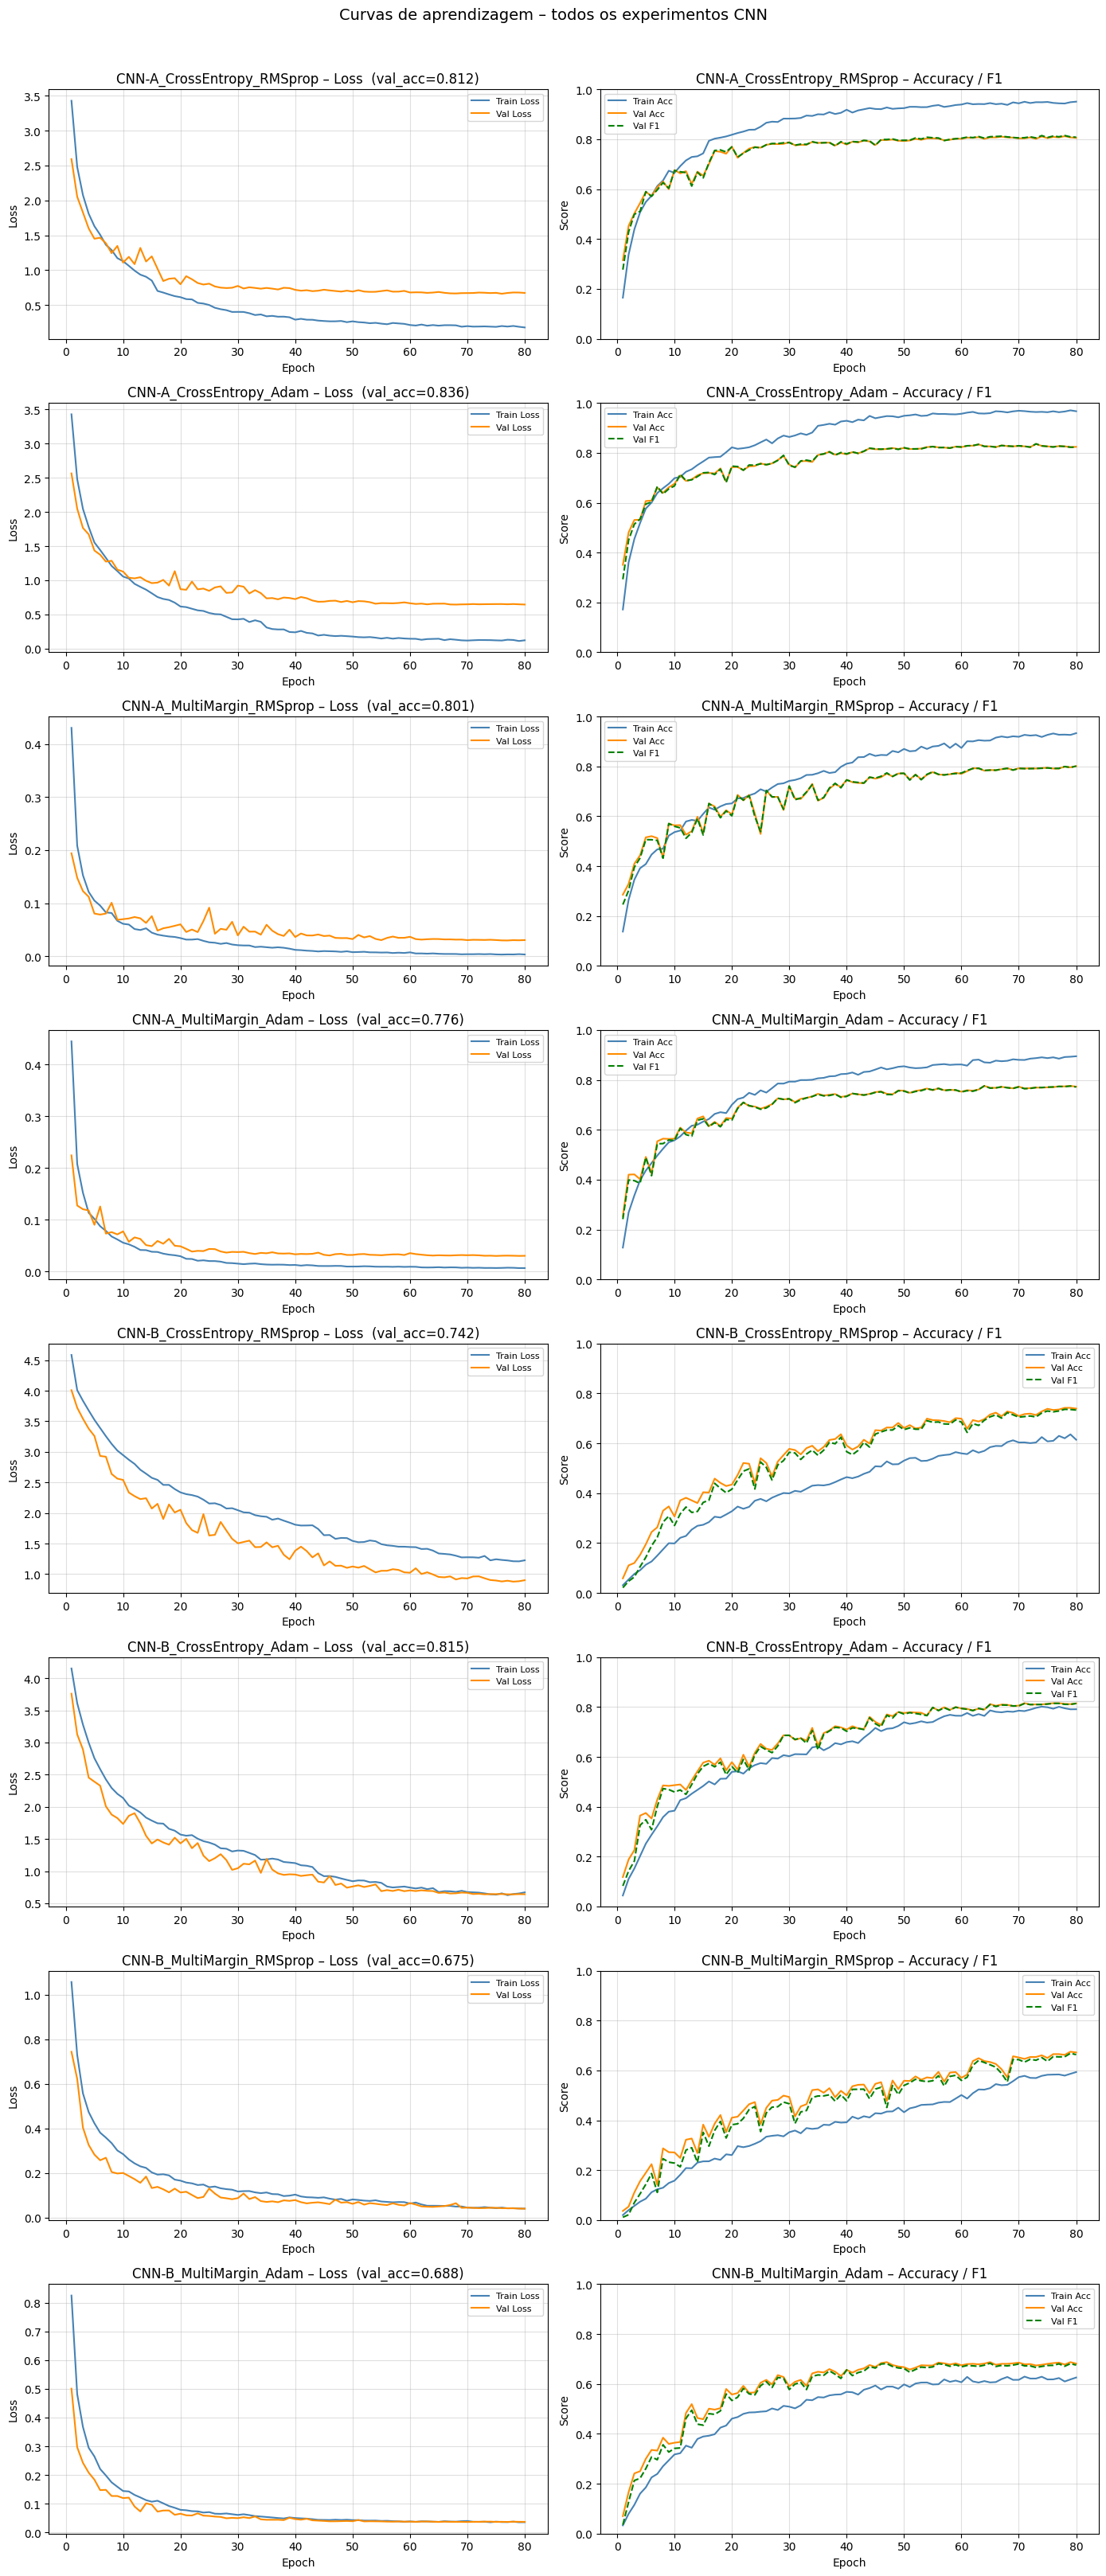

In [20]:
n_exp  = len(histories)
n_cols = 2          # Loss e Accuracy lado a lado
n_rows = n_exp       # uma linha por experimento

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
if n_rows == 1:
    axes = [axes]   # garantir que é sempre lista de linhas

for row_idx, (key, h) in enumerate(histories.items()):
    val_acc_exp = results[key]['val_acc']
    epochs = range(1, len(h['train_loss']) + 1)

    ax_loss, ax_acc = axes[row_idx]

    # ── Loss ──
    ax_loss.plot(epochs, h['train_loss'], label='Train Loss', color='steelblue')
    ax_loss.plot(epochs, h['val_loss'],   label='Val Loss',   color='darkorange')
    ax_loss.set_title(f'{key} – Loss  (val_acc={val_acc_exp:.3f})')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.4)

    # ── Accuracy / F1 ──
    ax_acc.plot(epochs, h['train_acc'], label='Train Acc', color='steelblue')
    ax_acc.plot(epochs, h['val_acc'],   label='Val Acc',   color='darkorange')
    ax_acc.plot(epochs, h['val_f1'],    label='Val F1',    color='green', linestyle='--')
    ax_acc.set_title(f'{key} – Accuracy / F1')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Score')
    ax_acc.set_ylim(0, 1)
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.4)

plt.suptitle('Curvas de aprendizagem – todos os experimentos CNN', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import json
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import StepLR

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, top_k_accuracy_score
)

import kagglehub

# Reproducibilidade
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: mps


/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### 6.3 Guardar Resultados

Guardamos os resultados em CSV para comparação final no notebook `05_results.ipynb`.

In [30]:
import os, pandas as pd, numpy as np, torch
os.makedirs('../outputs/results', exist_ok=True)

rows = []
for key, r in results.items():
    rows.append({
        'Model':        'CNN',
        'Experiment':   key,
        'Val Accuracy': round(r['val_acc'],  4),
        'Macro F1':     round(r['val_f1'],   4),
        'Top-5 Acc':    round(r['val_top5'], 4),
    })

df_cnn = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False)
df_cnn.to_csv('../outputs/results/cnn_results.csv', index=False)
print('Resultados guardados em ../outputs/results/cnn_results.csv')

# Guardar melhor modelo e previsões para uso independente em 6.4 / 6.5
best_key = max(results, key=lambda k: results[k]['val_acc'])
torch.save(models[best_key].state_dict(), '../outputs/results/cnn_best_model.pth')
np.save('../outputs/results/cnn_best_preds.npy',  np.array(results[best_key]['preds']))
np.save('../outputs/results/cnn_best_labels.npy', np.array(results[best_key]['labels']))
with open('../outputs/results/cnn_best_key.txt', 'w') as _f:
    _f.write(best_key)
print(f'Melhor modelo guardado: {best_key}')
df_cnn


NameError: name 'results' is not defined

### 6.4 Curvas de todos os experimentos (Val Accuracy)

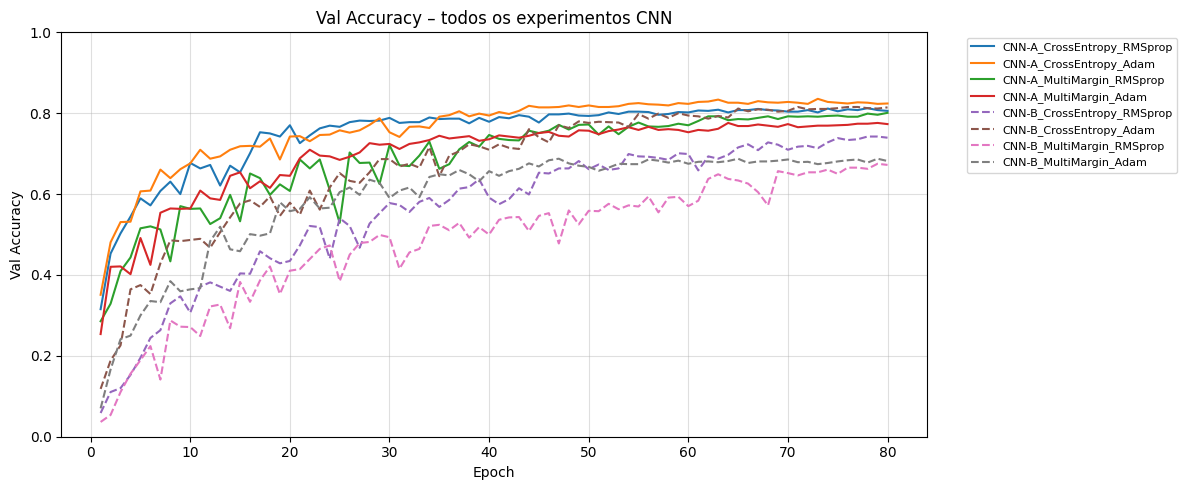

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
for key, h in histories.items():
    style = '-' if 'CNN-A' in key else '--'
    ax.plot(range(1, len(h['val_acc'])+1), h['val_acc'],
            linestyle=style, label=key)
ax.set_title('Val Accuracy – todos os experimentos CNN')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Accuracy')
ax.set_ylim(0, 1)
ax.legend(bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 6.5 Matriz de confusão (melhor experimento)

Melhor experimento: CNN-A_CrossEntropy_Adam


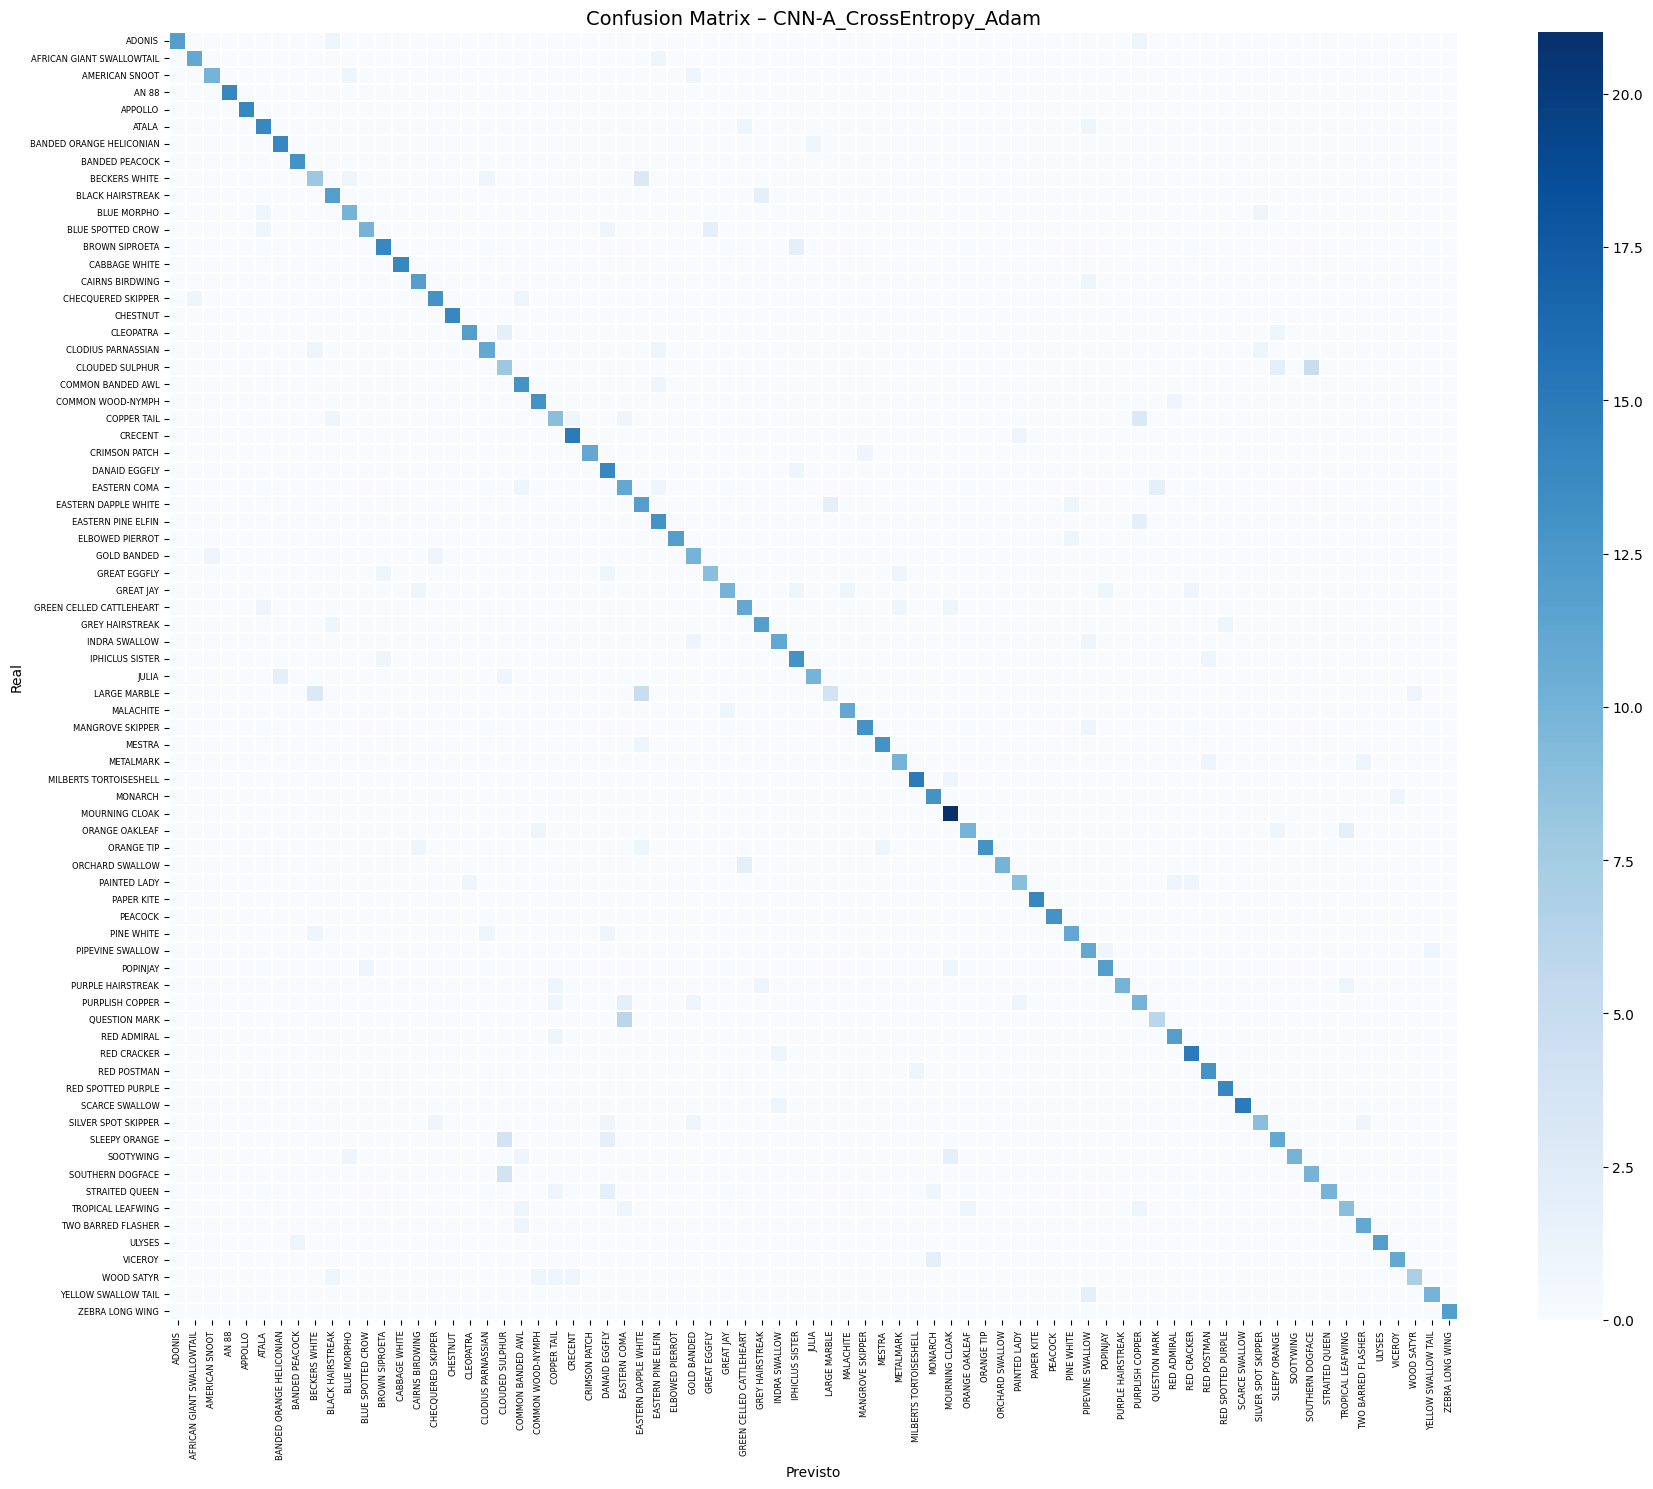

In [28]:
import numpy as np

# Tenta usar resultados em memória; caso contrário carrega do disco
try:
    _best_key    = max(results, key=lambda k: results[k]['val_acc'])
    _best_preds  = results[_best_key]['preds']
    _best_labels = results[_best_key]['labels']
except NameError:
    _best_key    = open('../results/cnn_best_key.txt').read().strip()
    _best_preds  = np.load('../results/cnn_best_preds.npy').tolist()
    _best_labels = np.load('../results/cnn_best_labels.npy').tolist()
    print(f'[Carregado do disco] Melhor experimento: {_best_key}')

print(f'Melhor experimento: {_best_key}')

cm = confusion_matrix(_best_labels, _best_preds)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    cm, ax=ax,
    xticklabels=classes, yticklabels=classes,
    cmap='Blues', linewidths=0.3,
    annot=False
)
ax.set_title(f'Confusion Matrix – {_best_key}', fontsize=14)
ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
ax.tick_params(axis='x', rotation=90, labelsize=6)
ax.tick_params(axis='y', rotation=0,  labelsize=6)
plt.tight_layout()
plt.show()


### 6.6 Relatório de classificação (melhor experimento)

In [30]:
import numpy as np

try:
    _best_key    = max(results, key=lambda k: results[k]['val_acc'])
    _best_preds  = results[_best_key]['preds']
    _best_labels = results[_best_key]['labels']
except NameError:
    _best_key    = open('../results/cnn_best_key.txt').read().strip()
    _best_preds  = np.load('../results/cnn_best_preds.npy').tolist()
    _best_labels = np.load('../results/cnn_best_labels.npy').tolist()
    print(f'[Carregado do disco] Melhor experimento: {_best_key}')

print(classification_report(
    _best_labels, _best_preds,
    target_names=classes,
    zero_division=0
))


                           precision    recall  f1-score   support

                   ADONIS       1.00      0.86      0.92        14
AFRICAN GIANT SWALLOWTAIL       0.92      0.92      0.92        12
           AMERICAN SNOOT       0.91      0.83      0.87        12
                    AN 88       1.00      1.00      1.00        14
                  APPOLLO       1.00      1.00      1.00        14
                    ATALA       0.82      0.88      0.85        16
 BANDED ORANGE HELICONIAN       0.88      0.93      0.90        15
           BANDED PEACOCK       0.93      1.00      0.96        13
            BECKERS WHITE       0.62      0.62      0.62        13
         BLACK HAIRSTREAK       0.75      0.86      0.80        14
              BLUE MORPHO       0.77      0.83      0.80        12
        BLUE SPOTTED CROW       0.91      0.71      0.80        14
           BROWN SIPROETA       0.88      0.88      0.88        16
            CABBAGE WHITE       1.00      1.00      1.00     

## 7. Análise e Conclusões

### CNN vs MLP para classificação de imagens
As CNNs exploram explicitamente a **estrutura espacial** das imagens através de filtros convolucionais partilhados:
- **Partilha de pesos**: o mesmo filtro é aplicado em toda a imagem → muito menos parâmetros que o MLP para a mesma capacidade representativa.
- **Invariância à translação**: MaxPooling e convoluções tornam o modelo robusto a pequenas deslocações do motivo.
- **Hierarquia de features**: camadas iniciais detetam bordas/texturas; camadas profundas combinam-nas em padrões complexos (ex: padrões de asas).

### Comparação de arquitecturas
- **CNN-A** (3 blocos, mais parâmetros FC): mais susceptível a overfitting nas camadas lineares.
- **CNN-B** (6 blocos + AdaptiveAvgPool): head FC mais pequeno → melhor regularização, geralmente superior em datasets pequenos.

### Comparação de losses
- **CrossEntropyLoss**: geralmente melhor resultado; penalização contínua por probabilidade.
- **MultiMarginLoss**: maximiza margens; pode convergir mais lentamente em CNN.

### Limitações
- Sem pre-training (treino de raiz): limita a capacidade de generalização comparativamente a modelos pré-treinados (ver `04_resnet.ipynb`).
- Dataset pequeno (~5200 imagens / 75 classes): overfitting ainda presente, mesmo com augmentation.

## 8. Grid Search

Com base na análise das curvas de aprendizagem (secção 6.2), os modelos CNN convergem mais lentamente do que os MLP.  
Fixamos **60 epochs** para a grid search (sweet spot entre CrossEntropy+Adam que estabiliza ~epoch 50 e CNN-B+MultiMargin que ainda sobe mas com ganhos marginais a partir daí).

| Hiperparâmetro | Valores pesquisados |
|---|---|
| Arquitectura | `CNN_A` · `CNN_B` |
| Learning Rate | `1e-4` · `1e-3` |
| Batch Size | `32` · `64` |
| Dropout | `0.3` · `0.5` |
| Loss | `CrossEntropy` · `MultiMargin` |
| Optimizer | `Adam` · `RMSprop` |

**Total: 2 × 2 × 2 × 2 × 2 x 2 = 64 combinações.**

In [20]:
import itertools

GS_EPOCHS_CNN = 60

PARAM_GRID_CNN = {
    'arch'       : [('A', CNN_A), ('B', CNN_B)],
    'lr'         : [1e-4, 1e-3],
    'batch_size' : [32, 64],
    'dropout'    : [0.3, 0.5],
    'loss'       : ['CrossEntropy', 'MultiMargin'],
    'optimizer'  : ['Adam', 'RMSprop'],
}

keys_order = ['arch', 'lr', 'batch_size', 'dropout', 'loss', 'optimizer']
all_combos_cnn = list(itertools.product(*[PARAM_GRID_CNN[k] for k in keys_order]))
print(f'Total de combinações: {len(all_combos_cnn)}')

gs_results_cnn = {}
_current_bs_cnn = None
_train_loader_cnn_gs = None
_val_loader_cnn_gs   = None

for combo in all_combos_cnn:
    (arch_name, arch_cls), lr, batch_size, dropout, loss_name, opt_name = combo
    run_key = f'CNN-{arch_name}_lr={lr}_bs={batch_size}_drop={dropout}_ls={loss_name}_opt={opt_name}'
    print(f'\n>>> {run_key}')

    # Recriar dataloaders apenas quando o batch_size muda
    if batch_size != _current_bs_cnn:
        _current_bs_cnn = batch_size
        _train_loader_cnn_gs = data.DataLoader(
            train_ds, batch_size=batch_size, shuffle=True,
            num_workers=0
        )
        _val_loader_cnn_gs = data.DataLoader(
            val_ds, batch_size=batch_size, shuffle=False,
            num_workers=0
        )
        print(f'  [DataLoaders recriados com batch_size={batch_size}]')

    # Instanciar modelo
    model = arch_cls(num_classes=NUM_CLASSES, dropout=dropout).to(DEVICE)

    if loss_name == 'CrossEntropy':
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.MultiMarginLoss()

    if opt_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc   = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(1, GS_EPOCHS_CNN + 1):
        tr_loss, tr_acc = train_one_epoch(model, _train_loader_cnn_gs, criterion, optimizer, DEVICE)
        vl_loss, vl_acc, vl_f1, vl_top5, _, _ = evaluate(model, _val_loader_cnn_gs, criterion, DEVICE)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{GS_EPOCHS_CNN} | '
                  f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | '
                  f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} F1={vl_f1:.3f}')

    # Avalia o melhor modelo
    model.load_state_dict(best_model_wts)
    _, final_acc, final_f1, final_top5, _, _ = evaluate(model, _val_loader_cnn_gs, criterion, DEVICE)
    elapsed = time.time() - t0
    print(f'  Tempo: {elapsed:.1f}s | Best val_acc: {best_val_acc:.4f} | Final val_acc: {final_acc:.4f}')

    gs_results_cnn[run_key] = {
        'arch'        : arch_name,
        'lr'          : lr,
        'batch_size'  : batch_size,
        'dropout'     : dropout,
        'loss'        : loss_name,
        'optimizer'   : opt_name,
        'best_val_acc': best_val_acc,
        'val_acc'     : final_acc,
        'val_f1'      : final_f1,
        'val_top5'    : final_top5,
        'history'     : history,
    }

print('\n\nGrid Search CNN concluída!')


Total de combinações: 64

>>> CNN-A_lr=0.0001_bs=32_drop=0.3_ls=CrossEntropy_opt=Adam
  [DataLoaders recriados com batch_size=32]
  Epoch   1/60 | TrLoss=3.5450 TrAcc=0.181 | VlLoss=2.9216 VlAcc=0.367 F1=0.326
  Epoch  10/60 | TrLoss=1.3645 TrAcc=0.701 | VlLoss=1.3607 VlAcc=0.679 F1=0.674
  Epoch  20/60 | TrLoss=0.8323 TrAcc=0.805 | VlLoss=1.0157 VlAcc=0.748 F1=0.749
  Epoch  30/60 | TrLoss=0.5452 TrAcc=0.879 | VlLoss=0.9044 VlAcc=0.757 F1=0.752
  Epoch  40/60 | TrLoss=0.3933 TrAcc=0.913 | VlLoss=0.8144 VlAcc=0.766 F1=0.764
  Epoch  50/60 | TrLoss=0.3111 TrAcc=0.926 | VlLoss=0.7911 VlAcc=0.780 F1=0.779
  Epoch  60/60 | TrLoss=0.2525 TrAcc=0.942 | VlLoss=0.7544 VlAcc=0.784 F1=0.783
  Tempo: 801.7s | Best val_acc: 0.7837 | Final val_acc: 0.7837

>>> CNN-A_lr=0.0001_bs=32_drop=0.3_ls=CrossEntropy_opt=RMSprop
  Epoch   1/60 | TrLoss=3.3662 TrAcc=0.217 | VlLoss=2.7474 VlAcc=0.394 F1=0.358
  Epoch  10/60 | TrLoss=1.3037 TrAcc=0.705 | VlLoss=1.3370 VlAcc=0.670 F1=0.664
  Epoch  20/60 | TrLoss

In [21]:
# ── Tabela de resultados da grid search CNN ──────────────────────────────────
gs_rows_cnn = []
for key, r in gs_results_cnn.items():
    gs_rows_cnn.append({
        'Arquitectura' : f'CNN-{r["arch"]}',
        'LR'           : r['lr'],
        'Batch Size'   : r['batch_size'],
        'Dropout'      : r['dropout'],
        'Loss'         : r['loss'],
        'Optimizer'    : r['optimizer'],
        'Best Val Acc' : round(r['best_val_acc'], 4),
        'Val Accuracy' : round(r['val_acc'],    4),
        'Macro F1'     : round(r['val_f1'],     4),
        'Top-5 Acc'    : round(r['val_top5'],   4),
    })

df_gs_cnn = pd.DataFrame(gs_rows_cnn).sort_values('Best Val Acc', ascending=False)
print('Top 10 configurações:')
display(df_gs_cnn.head(10))

best_gs_cnn = df_gs_cnn.iloc[0]
print(f'\nMelhor configuração:')
print(f"  Arquitectura : {best_gs_cnn['Arquitectura']}")
print(f"  LR           : {best_gs_cnn['LR']}")
print(f"  Batch Size   : {best_gs_cnn['Batch Size']}")
print(f"  Dropout      : {best_gs_cnn['Dropout']}")
print(f"  Loss         : {best_gs_cnn['Loss']}")
print(f"  Optimizer    : {best_gs_cnn['Optimizer']}")
print(f"  Val Accuracy : {best_gs_cnn['Best Val Acc']:.4f}")


Top 10 configurações:


,Arquitectura,LR,Batch Size,Dropout,Loss,Optimizer,Best Val Acc,Val Accuracy,Macro F1,Top-5 Acc
20,CNN-A,0.0010,32,0.5,CrossEntropy,Adam,0.8096,0.8096,0.8100,0.9692
28,CNN-A,0.0010,64,0.5,CrossEntropy,Adam,0.8019,0.8019,0.8038,0.9433
48,CNN-B,0.0010,32,0.3,CrossEntropy,Adam,0.8000,0.8000,0.7995,0.9587
25,CNN-A,0.0010,64,0.3,CrossEntropy,RMSprop,0.8000,0.8000,0.8003,0.9558
16,CNN-A,0.0010,32,0.3,CrossEntropy,Adam,0.7981,0.7981,0.7994,0.9587
29,CNN-A,0.0010,64,0.5,CrossEntropy,RMSprop,0.7962,0.7962,0.7954,0.9462
17,CNN-A,0.0010,32,0.3,CrossEntropy,RMSprop,0.7962,0.7962,0.7976,0.9577
32,CNN-B,0.0001,32,0.3,CrossEntropy,Adam,0.7952,0.7952,0.7931,0.9538
1,CNN-A,0.0001,32,0.3,CrossEntropy,RMSprop,0.7942,0.7942,0.7972,0.9462
21,CNN-A,0.0010,32,0.5,CrossEntropy,RMSprop,0.7923,0.7923,0.7893,0.9558



Melhor configuração:
  Arquitectura : CNN-A
  LR           : 0.001
  Batch Size   : 32
  Dropout      : 0.5
  Loss         : CrossEntropy
  Optimizer    : Adam
  Val Accuracy : 0.8096


In [29]:
# ── Guardar resultados da grid search CNN ─────────────────────────────────────
os.makedirs('../outputs/results', exist_ok=True)
df_gs_cnn.to_csv('../outputs/results/cnn_gs_results.csv', index=False)
print('Resultados guardados em ../outputs/results/cnn_gs_results.csv')
df_gs_cnn


Resultados guardados em ../outputs/results/cnn_gs_results.csv


,Arquitectura,LR,Batch Size,Dropout,Loss,Optimizer,Best Val Acc,Val Accuracy,Macro F1,Top-5 Acc
20,CNN-A,0.001,32,0.5,CrossEntropy,Adam,0.8096,0.8096,0.8100,0.9692
28,CNN-A,0.001,64,0.5,CrossEntropy,Adam,0.8019,0.8019,0.8038,0.9433
48,CNN-B,0.001,32,0.3,CrossEntropy,Adam,0.8000,0.8000,0.7995,0.9587
25,CNN-A,0.001,64,0.3,CrossEntropy,RMSprop,0.8000,0.8000,0.8003,0.9558
16,CNN-A,0.001,32,0.3,CrossEntropy,Adam,0.7981,0.7981,0.7994,0.9587
...,...,...,...,...,...,...,...,...,...,...
62,CNN-B,0.001,64,0.5,MultiMargin,Adam,0.6750,0.6750,0.6718,0.9288
59,CNN-B,0.001,64,0.3,MultiMargin,RMSprop,0.6673,0.6673,0.6597,0.9327
51,CNN-B,0.001,32,0.3,MultiMargin,RMSprop,0.6663,0.6663,0.6589,0.9279
55,CNN-B,0.001,32,0.5,MultiMargin,RMSprop,0.6587,0.6587,0.6473,0.9135


## 8. Fase 2 – Fine-tuning: Top 5 + Variação de Filtros

Partindo dos **5 melhores resultados** da Grid Search (determinados por `Best Val Acc`),
treinamos cada configuração com dois novos valores de filtros iniciais — **16** e **64** —
e aumentamos o número de épocas para **80** (em vez dos 60 da Grid Search).

O valor **32** já foi testado na Grid Search, por isso é omitido aqui para maximizar
a informação nova obtida com o tempo de treino disponível.

| Top | Arquitectura | LR | Batch | Dropout | Loss | Optimizer | Best Val Acc (GS) |
|-----|---|---|---|---|---|---|---|
| 1 | CNN-A | 0.001 | 32 | 0.5 | CrossEntropy | Adam | 0.8096 |
| 2 | CNN-A | 0.001 | 64 | 0.5 | CrossEntropy | Adam | 0.8019 |
| 3 | CNN-B | 0.001 | 32 | 0.3 | CrossEntropy | Adam | 0.8000 |
| 4 | CNN-A | 0.001 | 64 | 0.3 | CrossEntropy | RMSprop | 0.8000 |
| 5 | CNN-A | 0.001 | 32 | 0.3 | CrossEntropy | Adam | 0.7981 |

In [26]:
import pandas as pd
import copy, time

PHASE2_EPOCHS = 80
INIT_FILTERS_LIST = [16, 64]   # 32 já foi testado na Grid Search

# Top 5 configurações da Grid Search
TOP5_CONFIGS = [
    {'arch': 'A', 'arch_cls': CNN_A, 'lr': 1e-3, 'batch_size': 32, 'dropout': 0.5, 'loss': 'CrossEntropy', 'optimizer': 'Adam'},
    {'arch': 'A', 'arch_cls': CNN_A, 'lr': 1e-3, 'batch_size': 64, 'dropout': 0.5, 'loss': 'CrossEntropy', 'optimizer': 'Adam'},
    {'arch': 'B', 'arch_cls': CNN_B, 'lr': 1e-3, 'batch_size': 32, 'dropout': 0.3, 'loss': 'CrossEntropy', 'optimizer': 'Adam'},
    {'arch': 'A', 'arch_cls': CNN_A, 'lr': 1e-3, 'batch_size': 64, 'dropout': 0.3, 'loss': 'CrossEntropy', 'optimizer': 'RMSprop'},
    {'arch': 'A', 'arch_cls': CNN_A, 'lr': 1e-3, 'batch_size': 32, 'dropout': 0.3, 'loss': 'CrossEntropy', 'optimizer': 'Adam'},
]

phase2_results = {}
_current_bs_p2 = None
_train_loader_p2 = None
_val_loader_p2   = None

total_runs = len(TOP5_CONFIGS) * len(INIT_FILTERS_LIST)
print(f'Total de runs na Fase 2: {total_runs}  ({len(TOP5_CONFIGS)} configs × {len(INIT_FILTERS_LIST)} filtros)\n')

for cfg in TOP5_CONFIGS:
    for init_f in INIT_FILTERS_LIST:
        run_key = (
            f'CNN-{cfg["arch"]}_lr={cfg["lr"]}_bs={cfg["batch_size"]}'
            f'_drop={cfg["dropout"]}_ls={cfg["loss"]}'
            f'_opt={cfg["optimizer"]}_f={init_f}'
        )
        print(f'>>> {run_key}')

        # Recriar dataloaders apenas quando o batch_size muda
        if cfg['batch_size'] != _current_bs_p2:
            _current_bs_p2 = cfg['batch_size']
            _train_loader_p2 = data.DataLoader(
                train_ds, batch_size=cfg['batch_size'], shuffle=True,
                num_workers=0
            )
            _val_loader_p2 = data.DataLoader(
                val_ds, batch_size=cfg['batch_size'], shuffle=False,
                num_workers=0
            )
            print(f'  [DataLoaders recriados com batch_size={cfg["batch_size"]}]')

        # Instanciar modelo com init_filters
        model = cfg['arch_cls'](
            num_classes=NUM_CLASSES,
            dropout=cfg['dropout'],
            init_filters=init_f
        ).to(DEVICE)
        params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Parâmetros: {params:,}')

        # Loss
        if cfg['loss'] == 'CrossEntropy':
            criterion = nn.CrossEntropyLoss()
        else:
            criterion = nn.MultiMarginLoss()

        # Optimizer
        if cfg['optimizer'] == 'Adam':
            optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
        else:
            optimizer = torch.optim.RMSprop(model.parameters(), lr=cfg['lr'])

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=5
        )

        best_val_acc   = 0.0
        best_model_wts = copy.deepcopy(model.state_dict())
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        t0 = time.time()
        for epoch in range(1, PHASE2_EPOCHS + 1):
            tr_loss, tr_acc = train_one_epoch(model, _train_loader_p2, criterion, optimizer, DEVICE)
            vl_loss, vl_acc, vl_f1, vl_top5, _, _ = evaluate(model, _val_loader_p2, criterion, DEVICE)
            scheduler.step(vl_acc)

            history['train_loss'].append(tr_loss)
            history['train_acc'].append(tr_acc)
            history['val_loss'].append(vl_loss)
            history['val_acc'].append(vl_acc)

            if vl_acc > best_val_acc:
                best_val_acc   = vl_acc
                best_model_wts = copy.deepcopy(model.state_dict())

            if epoch % 10 == 0 or epoch == 1:
                print(f'  Epoch {epoch:3d}/{PHASE2_EPOCHS} | '
                      f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.3f} | '
                      f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.3f} F1={vl_f1:.3f} Top5={vl_top5:.3f}')

        # Avalia o melhor modelo
        model.load_state_dict(best_model_wts)
        _, final_acc, final_f1, final_top5, _, _ = evaluate(model, _val_loader_p2, criterion, DEVICE)
        elapsed = time.time() - t0
        print(f'  Tempo: {elapsed:.1f}s | Best val_acc: {best_val_acc:.4f} | Final val_acc: {final_acc:.4f}\n')

        phase2_results[run_key] = {
            'arch'         : f'CNN-{cfg["arch"]}',
            'init_filters' : init_f,
            'lr'           : cfg['lr'],
            'batch_size'   : cfg['batch_size'],
            'dropout'      : cfg['dropout'],
            'loss'         : cfg['loss'],
            'optimizer'    : cfg['optimizer'],
            'best_val_acc' : best_val_acc,
            'val_acc'      : final_acc,
            'val_f1'       : final_f1,
            'val_top5'     : final_top5,
            'history'      : history,
        }

print('\n✓ Fase 2 concluída!')

Total de runs na Fase 2: 10  (5 configs × 2 filtros)

>>> CNN-A_lr=0.001_bs=32_drop=0.5_ls=CrossEntropy_opt=Adam_f=16
  [DataLoaders recriados com batch_size=32]
  Parâmetros: 4,782,299
  Epoch   1/80 | TrLoss=3.4328 TrAcc=0.165 | VlLoss=2.5997 VlAcc=0.338 F1=0.300 Top5=0.690
  Epoch  10/80 | TrLoss=1.2089 TrAcc=0.655 | VlLoss=1.2378 VlAcc=0.633 F1=0.622 Top5=0.895
  Epoch  20/80 | TrLoss=0.8063 TrAcc=0.754 | VlLoss=0.9460 VlAcc=0.726 F1=0.723 Top5=0.923
  Epoch  30/80 | TrLoss=0.5239 TrAcc=0.837 | VlLoss=0.8765 VlAcc=0.756 F1=0.757 Top5=0.932
  Epoch  40/80 | TrLoss=0.3722 TrAcc=0.879 | VlLoss=0.8187 VlAcc=0.771 F1=0.770 Top5=0.944
  Epoch  50/80 | TrLoss=0.3053 TrAcc=0.906 | VlLoss=0.7899 VlAcc=0.787 F1=0.789 Top5=0.951
  Epoch  60/80 | TrLoss=0.2743 TrAcc=0.913 | VlLoss=0.7642 VlAcc=0.787 F1=0.789 Top5=0.951
  Epoch  70/80 | TrLoss=0.2463 TrAcc=0.925 | VlLoss=0.7621 VlAcc=0.784 F1=0.784 Top5=0.957
  Epoch  80/80 | TrLoss=0.2124 TrAcc=0.932 | VlLoss=0.7432 VlAcc=0.788 F1=0.789 Top5=0

In [28]:
# ── Tabela de resultados da Fase 2 ──────────────────────────────────────────
rows = []
for key, r in phase2_results.items():
    rows.append({
        'Arquitectura'  : r['arch'],
        'Init Filters'  : r['init_filters'],
        'LR'            : r['lr'],
        'Batch Size'    : r['batch_size'],
        'Dropout'       : r['dropout'],
        'Loss'          : r['loss'],
        'Optimizer'     : r['optimizer'],
        'Best Val Acc'  : round(r['best_val_acc'], 4),
        'Val Accuracy'  : round(r['val_acc'],      4),
        'Macro F1'      : round(r['val_f1'],       4),
        'Top-5 Acc'     : round(r['val_top5'],     4),
    })

df_phase2 = pd.DataFrame(rows).sort_values('Best Val Acc', ascending=False)
print(f'Melhor resultado Fase 2:')
best_p2 = df_phase2.iloc[0]
print(f'  {best_p2["Arquitectura"]} | filters={best_p2["Init Filters"]} | '
      f'lr={best_p2["LR"]} | bs={best_p2["Batch Size"]} | '
      f'drop={best_p2["Dropout"]} | opt={best_p2["Optimizer"]} → '
      f'Val Acc={best_p2["Best Val Acc"]:.4f}')
display(df_phase2)

# Guardar resultados
import os
os.makedirs('../outputs/results', exist_ok=True)
df_phase2.to_csv('../outputs/results/cnn_phase2_results.csv', index=False)
print('\nResultados guardados em ../outputs/results/cnn_phase2_results.csv')

Melhor resultado Fase 2:
  CNN-A | filters=64 | lr=0.001 | bs=32 | drop=0.5 | opt=Adam → Val Acc=0.8442


,Arquitectura,Init Filters,LR,Batch Size,Dropout,Loss,Optimizer,Best Val Acc,Val Accuracy,Macro F1,Top-5 Acc
1,CNN-A,64,0.001,32,0.5,CrossEntropy,Adam,0.8442,0.8442,0.8432,0.9683
9,CNN-A,64,0.001,32,0.3,CrossEntropy,Adam,0.8433,0.8433,0.8431,0.9654
3,CNN-A,64,0.001,64,0.5,CrossEntropy,Adam,0.8337,0.8337,0.8346,0.9663
7,CNN-A,64,0.001,64,0.3,CrossEntropy,RMSprop,0.8250,0.8250,0.8262,0.9673
5,CNN-B,64,0.001,32,0.3,CrossEntropy,Adam,0.8183,0.8183,0.8182,0.9606
4,CNN-B,16,0.001,32,0.3,CrossEntropy,Adam,0.8135,0.8135,0.8135,0.9548
2,CNN-A,16,0.001,64,0.5,CrossEntropy,Adam,0.8010,0.8010,0.8019,0.9596
8,CNN-A,16,0.001,32,0.3,CrossEntropy,Adam,0.7990,0.7990,0.7990,0.9558
0,CNN-A,16,0.001,32,0.5,CrossEntropy,Adam,0.7952,0.7952,0.7965,0.9538
6,CNN-A,16,0.001,64,0.3,CrossEntropy,RMSprop,0.7923,0.7923,0.7921,0.9442



Resultados guardados em ../outputs/results/cnn_phase2_results.csv
